In [7]:
from __future__ import annotations

from collections.abc import Mapping
from dataclasses import dataclass, field
from pathlib import Path
from typing import TYPE_CHECKING, Any

import numpy as np
import pandas as pd

if TYPE_CHECKING:
    from matplotlib.axes import Axes
    from matplotlib.figure import Figure


Number = int | float | np.integer | np.floating


@dataclass
class VisualizationCAGI5Benchmark:
    """Visualize per-element CAGI5 Pearson correlations as table cells with bars.

    Expected input shape:
        rows    = different experiments / model settings
        columns = CAGI5 elements
        values  = Pearson correlations, usually in [-1, 1]

    `additional_values` can add external baselines such as:
        {"alphagenome": {"LDLR": 0.42, "IRF4": 0.18}}

    `type` is an optional keyword argument with per-element annotations, e.g.:
        {"LDLR": "prom.", "IRF4": "enh."}
    """

    table: pd.DataFrame | Mapping[str, Mapping[str, Any]] | str | Path
    additional_values: Mapping[str, Mapping[str, Any]] | None = None
    type: Mapping[str, str] | str | None = None
    experiment_column: str | None = None
    _table: pd.DataFrame = field(init=False, repr=False)
    _additional_values: dict[str, dict[str, Any]] = field(init=False, repr=False)

    def __post_init__(self) -> None:
        self._table = self._normalize_table(self.table, self.experiment_column)
        self._additional_values = {
            str(row_name): dict(values)
            for row_name, values in (self.additional_values or {}).items()
        }

    @classmethod
    def from_csv(
        cls,
        path: str | Path,
        *,
        additional_values: Mapping[str, Mapping[str, Any]] | None = None,
        type: Mapping[str, str] | str | None = None,
        experiment_column: str | None = None,
    ) -> "VisualizationCAGI5Benchmark":
        return cls(
            path,
            additional_values=additional_values,
            type=type,
            experiment_column=experiment_column,
        )

    @property
    def dataframe(self) -> pd.DataFrame:
        """Return the combined numeric table used for visualization."""

        return self._combined_table().copy()

    def __add__(
        self, other: "VisualizationCAGI5Benchmark"
    ) -> "VisualizationCAGI5Benchmark":
        if not isinstance(other, VisualizationCAGI5Benchmark):
            return NotImplemented

        combined = pd.concat([self._table, other._table], axis=0, sort=False)
        combined = self._deduplicate_index(combined)

        additional_values: dict[str, dict[str, Any]] = {}
        for source in (self._additional_values, other._additional_values):
            for row_name, values in source.items():
                clean_name = self._next_free_name(row_name, additional_values)
                additional_values[clean_name] = dict(values)

        return VisualizationCAGI5Benchmark(
            combined,
            additional_values=additional_values,
            type=self.type or other.type,
        )

    def plot(
        self,
        *,
        title: str | None = None,
        figsize: tuple[float, float] | None = None,
        value_range: tuple[float, float] = (-1.0, 1.0),
        cmap_positive: str = "#5f8fc8",
        cmap_negative: str = "#ff0000",
        missing_text: str = "-",
        percent: bool = True,
        decimals: int = 0,
        row_height: float = 0.42,
        col_width: float = 1.2,
        label_width: float = 3.2,
        type_height: float = 0.32,
        save_path: str | Path | None = None,
        dpi: int = 200,
        ax: "Axes | None" = None,
    ) -> "Figure":
        """Draw and optionally save the CAGI5 benchmark visualization."""

        plt, Rectangle = self._import_matplotlib()
        data = self._combined_table()
        numeric = data.apply(pd.to_numeric, errors="coerce")
        if numeric.empty:
            raise ValueError("No rows to visualize.")

        elements = list(numeric.columns)
        experiments = list(numeric.index)
        type_by_element = self._normalize_type(elements)
        has_type_row = bool(type_by_element)

        n_rows = len(experiments) + (1 if has_type_row else 0)
        n_cols = len(elements) + 1
        total_width = label_width + col_width * len(elements)
        total_height = row_height * len(experiments) + 0.7
        if has_type_row:
            total_height += type_height
        if title:
            total_height += 0.35

        if figsize is None:
            figsize = (max(8.0, total_width), max(2.6, total_height))

        if ax is None:
            fig, ax = plt.subplots(figsize=figsize)
        else:
            fig = ax.figure

        ax.set_xlim(0, total_width)
        ax.set_ylim(0, total_height)
        ax.axis("off")

        top = total_height - (0.35 if title else 0.05)
        if title:
            ax.text(
                total_width / 2,
                total_height - 0.05,
                title,
                ha="center",
                va="top",
                fontsize=13,
                fontweight="bold",
            )

        header_y = top - row_height
        self._draw_cell(ax, 0, header_y, label_width, row_height, "Experiment", bold=True)
        for j, element in enumerate(elements):
            x = label_width + j * col_width
            self._draw_cell(ax, x, header_y, col_width, row_height, str(element), bold=True)

        y = header_y
        if has_type_row:
            y -= type_height
            self._draw_cell(ax, 0, y, label_width, type_height, "Type", bold=True)
            for j, element in enumerate(elements):
                x = label_width + j * col_width
                self._draw_cell(
                    ax,
                    x,
                    y,
                    col_width,
                    type_height,
                    type_by_element.get(element, ""),
                    fontsize=9,
                )

        for i, experiment in enumerate(experiments):
            y = header_y - (type_height if has_type_row else 0) - (i + 1) * row_height
            self._draw_cell(
                ax,
                0,
                y,
                label_width,
                row_height,
                str(experiment),
                ha="left",
                xpad=0.05,
            )
            for j, element in enumerate(elements):
                x = label_width + j * col_width
                value = numeric.iloc[i, j]
                self._draw_value_cell(
                    ax,
                    x,
                    y,
                    col_width,
                    row_height,
                    value,
                    value_range=value_range,
                    positive_color=cmap_positive,
                    negative_color=cmap_negative,
                    missing_text=missing_text,
                    percent=percent,
                    decimals=decimals,
                )

        if save_path is not None:
            fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

        return fig

    def save(self, path: str | Path, **plot_kwargs: Any) -> "Figure":
        """Convenience wrapper around `plot(save_path=...)`."""

        return self.plot(save_path=path, **plot_kwargs)

    def _combined_table(self) -> pd.DataFrame:
        table = self._table.copy()
        if self._additional_values:
            extra = pd.DataFrame.from_dict(self._additional_values, orient="index")
            table = pd.concat([table, extra], axis=0, sort=False)
        table = self._deduplicate_index(table)
        return table

    @staticmethod
    def _normalize_table(
        table: pd.DataFrame | Mapping[str, Mapping[str, Any]] | str | Path,
        experiment_column: str | None,
    ) -> pd.DataFrame:
        if isinstance(table, pd.DataFrame):
            df = table.copy()
        elif isinstance(table, (str, Path)):
            df = pd.read_csv(table)
        else:
            df = pd.DataFrame(table)
            if df.index.equals(pd.RangeIndex(len(df))):
                df = pd.DataFrame.from_dict(table, orient="index")

        if experiment_column is not None:
            if experiment_column not in df.columns:
                raise ValueError(f"Missing experiment column: {experiment_column!r}")
            df = df.set_index(experiment_column)
        elif "experiment" in df.columns:
            df = df.set_index("experiment")

        df.index = df.index.map(str)
        return df

    def _normalize_type(self, elements: list[str]) -> dict[str, str]:
        if self.type is None:
            return {}
        if isinstance(self.type, str):
            return {element: self.type for element in elements}
        return {str(element): str(value) for element, value in self.type.items()}

    @classmethod
    def _draw_cell(
        cls,
        ax: "Axes",
        x: float,
        y: float,
        width: float,
        height: float,
        text: str,
        *,
        bold: bool = False,
        fontsize: int = 10,
        ha: str = "center",
        xpad: float = 0.0,
    ) -> None:
        _, Rectangle = cls._import_matplotlib()
        ax.add_patch(
            Rectangle(
                (x, y),
                width,
                height,
                facecolor="white",
                edgecolor="#202020",
                linewidth=0.8,
            )
        )
        text_x = x + width / 2 if ha == "center" else x + xpad
        ax.text(
            text_x,
            y + height / 2,
            text,
            ha=ha,
            va="center",
            fontsize=fontsize,
            fontweight="bold" if bold else "normal",
        )

    @classmethod
    def _draw_value_cell(
        cls,
        ax: "Axes",
        x: float,
        y: float,
        width: float,
        height: float,
        value: Any,
        *,
        value_range: tuple[float, float],
        positive_color: str,
        negative_color: str,
        missing_text: str,
        percent: bool,
        decimals: int,
    ) -> None:
        _, Rectangle = cls._import_matplotlib()
        cls._draw_cell(ax, x, y, width, height, "")

        if pd.isna(value):
            ax.text(x + width / 2, y + height / 2, missing_text, ha="center", va="center")
            return

        value = float(value)
        lo, hi = value_range
        max_abs = max(abs(lo), abs(hi))
        if max_abs <= 0:
            raise ValueError("value_range must include a non-zero bound.")

        zero_x = x + width / 2
        max_bar_width = width / 2 - 0.05
        bar_width = min(abs(value) / max_abs, 1.0) * max_bar_width
        bar_height = height * 0.78
        bar_y = y + (height - bar_height) / 2

        if value >= 0:
            bar_x = zero_x
            color = positive_color
        else:
            bar_x = zero_x - bar_width
            color = negative_color

        ax.add_patch(
            Rectangle(
                (bar_x, bar_y),
                bar_width,
                bar_height,
                facecolor=color,
                edgecolor=color,
                alpha=0.9,
            )
        )
        ax.plot([zero_x, zero_x], [y, y + height], color="#202020", linewidth=0.35)

        label = cls._format_value(value, percent=percent, decimals=decimals)
        ax.text(x + width - 0.05, y + height / 2, label, ha="right", va="center", fontsize=10)

    @staticmethod
    def _format_value(value: float, *, percent: bool, decimals: int) -> str:
        if percent:
            return f"{value * 100:.{decimals}f}%"
        return f"{value:.{decimals}f}"

    @classmethod
    def _deduplicate_index(cls, df: pd.DataFrame) -> pd.DataFrame:
        counts: dict[str, int] = {}
        new_index = []
        for name in df.index.map(str):
            count = counts.get(name, 0)
            counts[name] = count + 1
            new_index.append(name if count == 0 else f"{name} ({count + 1})")
        result = df.copy()
        result.index = new_index
        return result

    @staticmethod
    def _next_free_name(name: str, existing: Mapping[str, Any]) -> str:
        if name not in existing:
            return name
        i = 2
        while f"{name} ({i})" in existing:
            i += 1
        return f"{name} ({i})"

    @staticmethod
    def _import_matplotlib() -> tuple[Any, Any]:
        try:
            import matplotlib.pyplot as plt
            from matplotlib.patches import Rectangle
        except ModuleNotFoundError as exc:
            raise ModuleNotFoundError(
                "VisualizationCAGI5Benchmark.plot() requires matplotlib. "
                "Install it with `pip install matplotlib`, or use `.dataframe` "
                "to inspect the merged benchmark table without plotting."
            ) from exc
        return plt, Rectangle

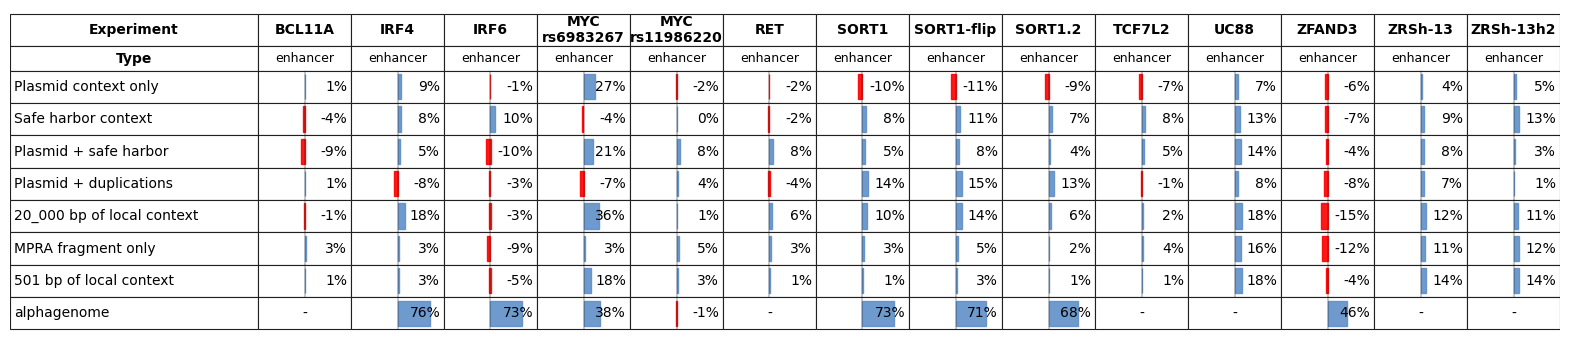

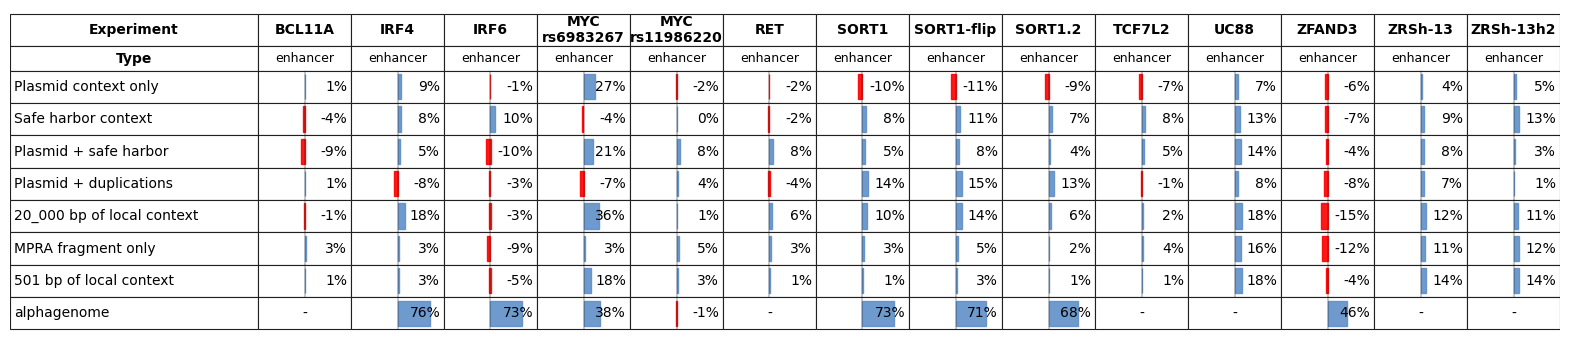

In [59]:
cagi5_results_ech = pd.read_csv('/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/cagi5_enhancer_corr_table.csv')
cagi5_results_ech.experiment = [
    'Plasmid context only',
    'Safe harbor context',
    'Plasmid + safe harbor',
    'Plasmid + duplications',
    '20_000 bp of local context',
    'MPRA fragment only',
    '501 bp of local context'
]
cagi5_results_ech.columns = ['experiment', 'BCL11A', 'IRF4', 'IRF6', 'MYC\nrs6983267', 'MYC\nrs11986220',
       'RET', 'SORT1', 'SORT1-flip', 'SORT1.2', 'TCF7L2', 'UC88', 'ZFAND3',
       'ZRSh-13', 'ZRSh-13h2']
viz = VisualizationCAGI5Benchmark(
    cagi5_results_ech,
    additional_values = {"alphagenome": {
                        'IRF4': 0.7578407931720138,
                        'IRF6': 0.7330310975924144,
                        'SORT1': 0.7332198547443374,
                        'SORT1-flip': 0.7080688021873313,
                        'SORT1.2': 0.6818988018755284,
                        'ZFAND3': 0.46458184661986546,
                        'MYC\nrs11986220': -0.006883612096113897,
                        'MYC\nrs6983267': 0.3841588266789807,}},
    type={el : "enhancer" for el in cagi5_results_ech.columns},
)
viz.plot()


In [29]:
CELL_TYPE = {
    # promoters
    "F9": "HepG2", "FOXE1": "HeLa", "GP1BA": "HEL92.1.7", 
    "HBB": "HEL92.1.7", "HBG1": "HEL92.1.7", "HNF4A": "HEK293T", 
    "LDLR": "HepG2", "LDLR.2": "HepG2", "MSMB": "HEK293T", 
    "PKLR-24h": "K562", "PKLR-48h": "K562", 
    "TERT-GAa": "SF7996", "TERT-GBM": "SF7996", 
    "TERT-GSc": "SF7996", "TERT-HEK": "HEK293T",
    # enhancers
    "BCL11A": "HEL92.1.7", "IRF4": "SK-MEL-28", "IRF6": "HaCaT", 
    "MYCrs6983267": "HEK293T", "MYCrs11986220": "LNCaP", 
    "RET": "Neuro-2a", "SORT1": "HepG2", "SORT1-flip": "HepG2", 
    "SORT1.2": "HepG2", "TCF7L2": "MIN6", "UC88": "Neuro-2a", 
    "ZFAND3": "MIN6", "ZRSh-13": "NIH-3T3", "ZRSh-13h2": "NIH-3T3"
}

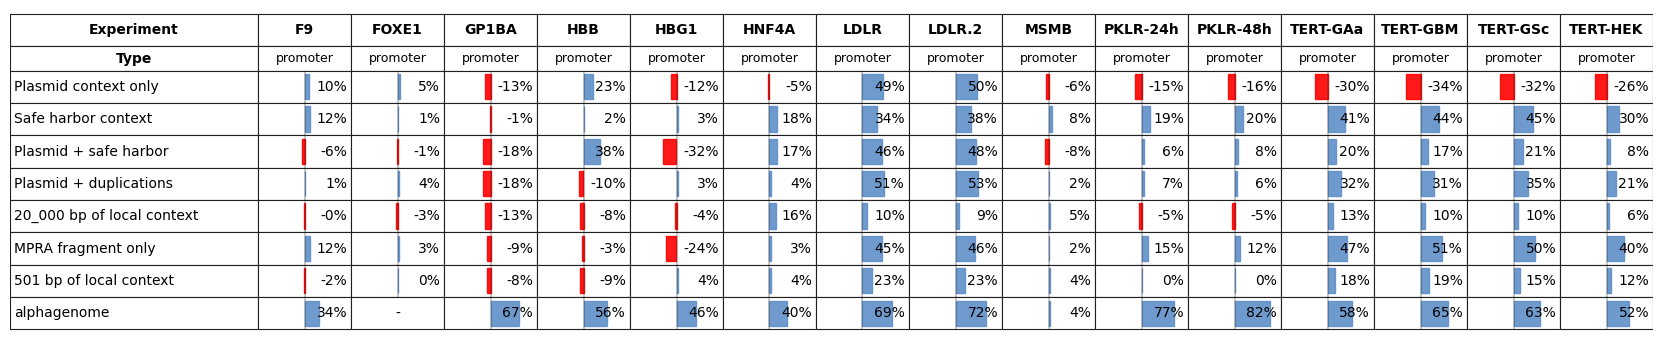

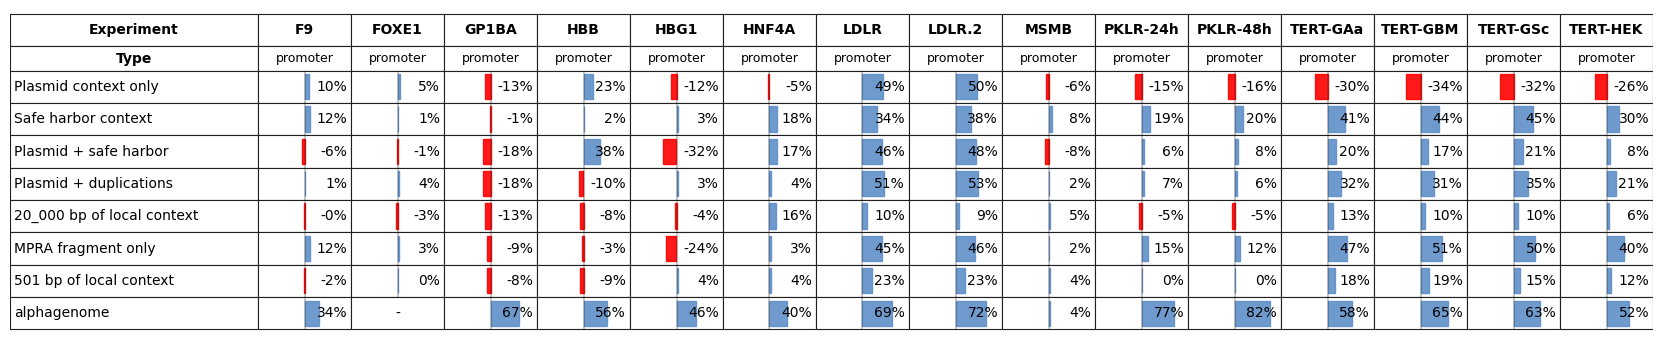

In [58]:
cagi5_results = pd.read_csv('/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/cagi5_promoter_corr_table.csv')
cagi5_results.experiment = [
    'Plasmid context only',
    'Safe harbor context',
    'Plasmid + safe harbor',
    'Plasmid + duplications',
    '20_000 bp of local context',
    'MPRA fragment only',
    '501 bp of local context'
]
#cagi5_results.columns = ['experiment', 'BCL11A', 'IRF4', 'IRF6', 'MYC\nrs6983267', 'MYC\nrs11986220',
#       'RET', 'SORT1', 'SORT1-flip', 'SORT1.2', 'TCF7L2', 'UC88', 'ZFAND3',
#       'ZRSh-13', 'ZRSh-13h2']
viz = VisualizationCAGI5Benchmark(
    cagi5_results,
    additional_values={"alphagenome": {'F9': 0.33692248099222705,
 'GP1BA': 0.6702685904516201,
 'HBB': 0.5561593718889403,
 'HBG1': 0.46471311984535446,
 'HNF4A': 0.3999849616567906,
 'LDLR': 0.6903359292243695,
 'LDLR.2': 0.7234711655047806,
 'MSMB': 0.04172098721458211,
 'PKLR-24h': 0.7695662046172251,
 'PKLR-48h': 0.8248098243662428,
 'TERT-GAa': 0.5825366274296809,
 'TERT-GBM': 0.6499560161950783,
 'TERT-GSc': 0.6318825409919112,
 'TERT-HEK': 0.5214542458381406,
}
},
    #additional_values={"cell_type": {el: CELL_TYPE[el] for el in cagi5_results.columns if el in CELL_TYPE}},
    type={el : "promoter" for el in cagi5_results.columns},
)
viz.plot()

In [33]:
{"cell_type": {el: CELL_TYPE[el] for el in cagi5_results.columns if el in CELL_TYPE}}

{'cell_type': {'F9': 'HepG2',
  'FOXE1': 'HeLa',
  'GP1BA': 'HEL92.1.7',
  'HBB': 'HEL92.1.7',
  'HBG1': 'HEL92.1.7',
  'HNF4A': 'HEK293T',
  'LDLR': 'HepG2',
  'LDLR.2': 'HepG2',
  'MSMB': 'HEK293T',
  'PKLR-24h': 'K562',
  'PKLR-48h': 'K562',
  'TERT-GAa': 'SF7996',
  'TERT-GBM': 'SF7996',
  'TERT-GSc': 'SF7996',
  'TERT-HEK': 'HEK293T'}}

In [1]:
import numpy as np
import polars as pl

def compute_element_correlations(
    result: pl.DataFrame,
    *,
    element_col="Element",
    target_col="Value",
    pred_col="alphagenome_score",
    method="pearson",
    min_n=2,
):
    """
    Returns:
        dict[element] = correlation between experimental Value and AlphaGenome score
    """

    if not isinstance(result, pl.DataFrame):
        result = pl.from_pandas(result)

    df = (
        result
        .select(element_col, target_col, pred_col)
        .drop_nulls([element_col, target_col, pred_col])
    )

    correlations = {}

    for key, group in df.partition_by(element_col, as_dict=True).items():
        element = key[0] if isinstance(key, tuple) else key

        x = group[target_col].cast(pl.Float64).to_numpy()
        y = group[pred_col].cast(pl.Float64).to_numpy()

        if len(x) < min_n or np.std(x) == 0 or np.std(y) == 0:
            correlations[element] = np.nan
            continue

        if method == "pearson":
            corr = np.corrcoef(x, y)[0, 1]

        elif method == "spearman":
            x_rank = pl.Series(x).rank("average").to_numpy()
            y_rank = pl.Series(y).rank("average").to_numpy()
            corr = np.corrcoef(x_rank, y_rank)[0, 1]

        else:
            raise ValueError("method must be 'pearson' or 'spearman'")

        correlations[element] = float(corr)

    return correlations

In [3]:
results = pl.read_csv('/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/alphagenome_cagi5_bench.tsv', separator='\t', infer_schema_length=10000)

In [17]:
a = ['F9',
 'GP1BA',
 'HBB',
 'HBG1',
 'HNF4A',
 'IRF4',
 'IRF6',
 'LDLR',
 'MSMB',
 'MYC',
 'PKLR',
 'SORT1',
 'TERT',
 'ZFAND3']

In [22]:
results['Element'].unique().to_list()

['IRF4',
 'BCL11A',
 'LDLR',
 'HBG1',
 'ZFAND3',
 'PKLR',
 'GP1BA',
 'HNF4A',
 'MYC',
 'UC88',
 'ZRSh',
 'F9',
 'TERT',
 'TCF7L2',
 'SORT1',
 'RET',
 'FOXE1',
 'IRF6',
 'HBB',
 'MSMB']

In [20]:
results['Element'].unique().map_elements(lambda x: x if x not in a else None).unique().to_list()

['UC88', 'RET', 'FOXE1', 'TCF7L2', 'BCL11A', 'ZRSh', None]

In [30]:
dataset = pl.read_csv('/home/jovyan/.cache/mpramnist/data/Kircher/Kircher_GRCh38_ALL.tsv', separator='\t', infer_schema_length=10000)
variant_expr = pl.lit('chr') + pl.col('Chromosome').cast(pl.String) + pl.lit(':') + (pl.col('Position') + 1).cast(pl.String) + pl.lit(':') + pl.col('Ref').str.replace('-', '') + pl.lit('>') + pl.col('Alt').str.replace('-', '')
dataset = dataset.with_columns(variant = variant_expr)
dataset = dataset.filter(pl.col.Tags.__gt__(10))

In [48]:
dataset = dataset.with_columns(id = pl.col('variant') +  pl.col.Tags.cast(pl.String) + pl.col.DNA.cast(pl.String) + pl.col.RNA.cast(pl.String) + pl.col('P-Value').cast(pl.String).str.replace('.', ''))

In [50]:
results = results.with_columns(id = pl.col('variant') +  pl.col.Tags.cast(pl.String) + pl.col.DNA.cast(pl.String) + pl.col.RNA.cast(pl.String) + pl.col('P-Value').cast(pl.String).str.replace('.', ''))

In [49]:
dataset

Element,Cell_Type,Chromosome,Position,Ref,Alt,Tags,DNA,RNA,Value,P-Value,variant,id
str,str,str,i64,str,str,i64,i64,i64,f64,f64,str,str
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""-""",32,577,1345,-0.34,0.00546,"""chr2:60494940:C>""","""chr2:60494940:C>325771345.0054…"
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""A""",146,2785,6772,-0.05,0.38889,"""chr2:60494940:C>A""","""chr2:60494940:C>A14627856772.3…"
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""G""",60,975,2436,-0.13,0.13721,"""chr2:60494940:C>G""","""chr2:60494940:C>G609752436.137…"
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""T""",1084,8543,16057,-0.7,0.0,"""chr2:60494940:C>T""","""chr2:60494940:C>T1084854316057…"
"""BCL11A""","""HEL92.1.7""","""2""",60494940,"""C""","""A""",596,9425,23430,-0.08,0.00413,"""chr2:60494941:C>A""","""chr2:60494941:C>A596942523430.…"
…,…,…,…,…,…,…,…,…,…,…,…,…
"""ZRSh-13h2""","""NIH-3T3""","""7""",156791601,"""G""","""T""",1676,12030,37310,0.1,0.00001,"""chr7:156791602:G>T""","""chr7:156791602:G>T167612030373…"
"""ZRSh-13h2""","""NIH-3T3""","""7""",156791602,"""C""","""-""",1447,11717,34300,0.04,0.11224,"""chr7:156791603:C>""","""chr7:156791603:C>1447117173430…"
"""ZRSh-13h2""","""NIH-3T3""","""7""",156791602,"""C""","""A""",25,107,309,-0.17,0.33374,"""chr7:156791603:C>A""","""chr7:156791603:C>A25107309.333…"


In [52]:
input = dataset.join(results, on='id', how='inner')

In [54]:
input

Element,Cell_Type,Chromosome,Position,Ref,Alt,Tags,DNA,RNA,Value,P-Value,variant,id,Element_right,Cell_Type_right,Chromosome_right,Position_right,Ref_right,Alt_right,Tags_right,DNA_right,RNA_right,Value_right,P-Value_right,variant_right,alphagenome_score,used_ontologies,ontology_scores
str,str,str,i64,str,str,i64,i64,i64,f64,f64,str,str,str,str,str,i64,str,str,i64,i64,i64,f64,f64,str,f64,str,str
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""-""",32,577,1345,-0.34,0.00546,"""chr2:60494940:C>""","""chr2:60494940:C>325771345.0054…","""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""-""",32,577,1345,-0.34,0.00546,"""chr2:60494940:C>""",null,null,null
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""A""",146,2785,6772,-0.05,0.38889,"""chr2:60494940:C>A""","""chr2:60494940:C>A14627856772.3…","""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""A""",146,2785,6772,-0.05,0.38889,"""chr2:60494940:C>A""",null,null,null
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""G""",60,975,2436,-0.13,0.13721,"""chr2:60494940:C>G""","""chr2:60494940:C>G609752436.137…","""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""G""",60,975,2436,-0.13,0.13721,"""chr2:60494940:C>G""",null,null,null
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""T""",1084,8543,16057,-0.7,0.0,"""chr2:60494940:C>T""","""chr2:60494940:C>T1084854316057…","""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""T""",1084,8543,16057,-0.7,0.0,"""chr2:60494940:C>T""",null,null,null
"""BCL11A""","""HEL92.1.7""","""2""",60494940,"""C""","""A""",596,9425,23430,-0.08,0.00413,"""chr2:60494941:C>A""","""chr2:60494941:C>A596942523430.…","""BCL11A""","""HEL92.1.7""","""2""",60494940,"""C""","""A""",596,9425,23430,-0.08,0.00413,"""chr2:60494941:C>A""",null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ZRSh-13h2""","""NIH-3T3""","""7""",156791601,"""G""","""T""",1676,12030,37310,0.1,0.00001,"""chr7:156791602:G>T""","""chr7:156791602:G>T167612030373…","""ZRSh""","""NIH-3T3""","""7""",156791601,"""G""","""T""",1676,12030,37310,0.1,0.00001,"""chr7:156791602:G>T""",null,null,null
"""ZRSh-13h2""","""NIH-3T3""","""7""",156791602,"""C""","""-""",1447,11717,34300,0.04,0.11224,"""chr7:156791603:C>""","""chr7:156791603:C>1447117173430…","""ZRSh""","""NIH-3T3""","""7""",156791602,"""C""","""-""",1447,11717,34300,0.04,0.11224,"""chr7:156791603:C>""",null,null,null
"""ZRSh-13h2""","""NIH-3T3""","""7""",156791602,"""C""","""A""",25,107,309,-0.17,0.33374,"""chr7:156791603:C>A""","""chr7:156791603:C>A25107309.333…","""ZRSh""","""NIH-3T3""","""7""",156791602,"""C""","""A""",25,107,309,-0.17,0.33374,"""chr7:156791603:C>A""",null,null,null


In [56]:
compute_element_correlations(input, element_col = 'Element')

{'F9': 0.33692248099222705,
 'GP1BA': 0.6702685904516201,
 'HBB': 0.5561593718889403,
 'HBG1': 0.46471311984535446,
 'HNF4A': 0.3999849616567906,
 'IRF4': 0.7578407931720138,
 'IRF6': 0.7330310975924144,
 'LDLR': 0.6903359292243695,
 'LDLR.2': 0.7234711655047806,
 'MSMB': 0.04172098721458211,
 'MYCrs11986220': -0.006883612096113897,
 'MYCrs6983267': 0.3841588266789807,
 'PKLR-24h': 0.7695662046172251,
 'PKLR-48h': 0.8248098243662428,
 'SORT1': 0.7332198547443374,
 'SORT1-flip': 0.7080688021873313,
 'SORT1.2': 0.6818988018755284,
 'TERT-GAa': 0.5825366274296809,
 'TERT-GBM': 0.6499560161950783,
 'TERT-GSc': 0.6318825409919112,
 'TERT-HEK': 0.5214542458381406,
 'ZFAND3': 0.46458184661986546}